:# DFJSS — Genetic Programming (RCPSP với Stochastic Duration & Transfer Time)

**Cấu trúc notebook:**
| Cell | Nội dung |
|------|----------|
| 1 | Cài đặt & import |
| 2 | `problem.py` — Cấu trúc dữ liệu bài toán |
| 3 | `gp_tree.py` — Cây biểu thức GP |
| 4 | `simulation.py` — Event-driven simulation |
| 5 | `gp_runner.py` — Vòng lặp GP |
| 6 | `main.py` — Instance generator |
| 7 | ▶ Chạy GP (config tùy chỉnh) |
| 8 | 📊 Visualize kết quả |

> **Cách dùng:** Chạy tuần tự từ Cell 1 → Cell 7.  
> Muốn thay đổi tham số GP → chỉnh Cell 7.  
> Muốn thay đổi instance → chỉnh Cell 6 hoặc Cell 7.


## Cell 1 — Cài đặt & Import

## Cell 2 — `problem.py`
Cấu trúc dữ liệu tĩnh: `ResourceType`, `ResourceUnit`, `Activity`, `Project`, `Scenario`, `ScheduleState`, `JobContext`, `TransferContext`.


In [1]:
"""
problem.py
──────────
Cấu trúc dữ liệu tĩnh của bài toán RCPSP với stochastic duration
và stochastic transfer time (DFJSS).

Phân cấp:
    Project          ← topology cố định
        Activity     ← một công đoạn (predecessors, resource_request)
        ResourceType ← loại nguồn lực (capacity)
    Scenario         ← một sample cụ thể của các biến ngẫu nhiên
    ScheduleState    ← trạng thái động trong simulation
"""


import random
from copy import deepcopy
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple


# ═══════════════════════════════════════════════════════════════════
# 1. Resource
# ═══════════════════════════════════════════════════════════════════

@dataclass
class ResourceType:
    """Định nghĩa một loại nguồn lực (VD: thợ hàn, xe nâng)."""
    id:       int
    name:     str
    capacity: int          # tổng số unit của loại này trong nhà máy


@dataclass
class ResourceUnit:
    """
    Một đơn vị nguồn lực cụ thể (VD: thợ hàn số 3).

    Sau khi activity hoàn thành, unit KHÔNG về depot mà ở lại
    tại location cũ, chờ RRTPR điều phối đến activity tiếp theo.
    """
    id:           int
    type_id:      int      # thuộc ResourceType nào
    location:     int      # đang ở activity nào; -1 = depot (chưa dùng)
    available_at: float    # thời điểm sớm nhất có thể được gán


# transfer_times[type_k][(act_i, act_j)] = (mu, sigma)
# Tra cứu O(1): E[Δ_ij^k] = mu, Var = sigma²
TransferTimeTable = Dict[int, Dict[Tuple[int, int], Tuple[float, float]]]


# ═══════════════════════════════════════════════════════════════════
# 2. Activity
# ═══════════════════════════════════════════════════════════════════

@dataclass
class Activity:
    """
    Một công đoạn trong dự án.
    """
    id:               int
    name:             str

    # Thời gian thực hiện — stochastic, phân phối LogNormal
    duration_mu:      float        # E[d_j]  — dùng làm terminal DT trong RAPR
    duration_sigma:   float        # độ lệch chuẩn

    # Ràng buộc thứ tự (Activity Precedence)
    predecessors:     List[int]    # list act_id phải xong trước j
    successors:       List[int]    # dùng tính terminal TS

    # Yêu cầu nguồn lực: type_k → số unit cần
    # VD: {0: 2, 1: 1} → cần 2 thợ hàn + 1 xe nâng
    resource_request: Dict[int, int] = field(default_factory=dict)


# ═══════════════════════════════════════════════════════════════════
# 3. Project — cấu trúc tĩnh
# ═══════════════════════════════════════════════════════════════════

@dataclass
class Project:
    """
    Topology bài toán — không thay đổi giữa các kịch bản.

    source_id: dummy activity đầu (duration=0, không cần resource)
    sink_id:   dummy activity cuối (duration=0, không cần resource)
    Makespan = finish_time[sink_id]
    """
    activities:     Dict[int, Activity]
    resource_types: Dict[int, ResourceType]
    transfer_times: TransferTimeTable
    source_id:      int
    sink_id:        int

    def compute_cpm(self) -> Dict[int, Dict[str, float]]:
        """
        Tính ES, EF, LS, LF, SLK cho từng activity
        bằng Critical Path Method (dùng duration_mu).

        Trả về dict: act_id → {'ES', 'EF', 'LS', 'LF', 'SLK'}
        """
        acts = self.activities
        topo = self._topological_order()

        # Forward pass — ES, EF
        ES: Dict[int, float] = {a: 0.0 for a in acts}
        EF: Dict[int, float] = {a: 0.0 for a in acts}
        for aid in topo:
            act = acts[aid]
            es = max((EF[p] for p in act.predecessors), default=0.0)
            ES[aid] = es
            EF[aid] = es + act.duration_mu

        project_end = EF[self.sink_id]

        # Backward pass — LF, LS
        LF: Dict[int, float] = {a: project_end for a in acts}
        LS: Dict[int, float] = {a: project_end for a in acts}
        for aid in reversed(topo):
            act = acts[aid]
            lf = min((LS[s] for s in act.successors), default=project_end)
            LF[aid] = lf
            LS[aid] = lf - act.duration_mu

        return {
            aid: {
                'ES':  ES[aid],
                'EF':  EF[aid],
                'LS':  LS[aid],
                'LF':  LF[aid],
                'SLK': LS[aid] - ES[aid],
            }
            for aid in acts
        }

    def _topological_order(self) -> List[int]:
        """Kahn's algorithm — sắp xếp topo từ source đến sink."""
        in_deg = {a: len(self.activities[a].predecessors)
                  for a in self.activities}
        queue = [a for a, d in in_deg.items() if d == 0]
        order = []
        while queue:
            node = queue.pop(0)
            order.append(node)
            for s in self.activities[node].successors:
                in_deg[s] -= 1
                if in_deg[s] == 0:
                    queue.append(s)
        return order


# ═══════════════════════════════════════════════════════════════════
# 4. Scenario — một sample cụ thể
# ═══════════════════════════════════════════════════════════════════

@dataclass
class Scenario:
    """
    Một kịch bản = project với tất cả biến ngẫu nhiên đã được sample.
    GP đánh giá fitness trên Q kịch bản như thế này.

    Các biến ngẫu nhiên:
      - realized_duration[act_id]              : thời gian thực hiện
      - realized_transfer_time[type_k][(i,j)] : thời gian di chuyển thực tế
    """
    id:      int
    project: Project

    realized_duration:      Dict[int, float]
    realized_transfer_time: Dict[int, Dict[Tuple[int, int], float]]


def generate_scenario(project: Project, scenario_id: int) -> Scenario:
    """
    Sample một kịch bản từ project bằng cách lấy mẫu:
      - duration:       LogNormal(mu, sigma) cho từng activity
      - transfer_time:  LogNormal(mu, sigma) cho từng cặp (i,j,k)

    Dùng phân phối LogNormal vì duration không âm và có right-skew
    phù hợp thực tế sản xuất.
    """
    import math

    def lognormal_sample(mu: float, sigma: float) -> float:
        """Sample từ LogNormal sao cho E[X] ≈ mu, Std[X] ≈ sigma."""
        if sigma <= 0:
            return mu
        # Chuyển (mu, sigma) sang tham số log-space
        cv2  = (sigma / mu) ** 2
        mu_ln  = math.log(mu / math.sqrt(1 + cv2))
        sig_ln = math.sqrt(math.log(1 + cv2))
        return random.lognormvariate(mu_ln, sig_ln)

    # Sample duration cho từng activity
    realized_duration = {}
    for aid, act in project.activities.items():
        realized_duration[aid] = lognormal_sample(
            act.duration_mu, act.duration_sigma
        )
    # Source và sink luôn = 0
    realized_duration[project.source_id] = 0.0
    realized_duration[project.sink_id]   = 0.0

    # Sample transfer time cho từng (type_k, act_i, act_j)
    realized_tt: Dict[int, Dict[Tuple[int, int], float]] = {}
    for type_k, tt_dict in project.transfer_times.items():
        realized_tt[type_k] = {}
        for (i, j), (mu, sigma) in tt_dict.items():
            realized_tt[type_k][(i, j)] = lognormal_sample(mu, sigma)

    return Scenario(
        id=scenario_id,
        project=project,
        realized_duration=realized_duration,
        realized_transfer_time=realized_tt,
    )


def generate_scenario_set(project: Project, Q: int) -> List[Scenario]:
    """Sinh tập Q kịch bản, cố định trong 1 generation."""
    return [generate_scenario(project, i) for i in range(Q)]


# ═══════════════════════════════════════════════════════════════════
# 5. ScheduleState — trạng thái động
# ═══════════════════════════════════════════════════════════════════

@dataclass
class ScheduleState:
    """
    Trạng thái nhà máy tại thời điểm t trong một simulation run.
    Thay đổi theo từng event.
    """
    t: float = 0.0

    # Trạng thái từng activity
    status:     Dict[int, str]   = field(default_factory=dict)
    # "waiting" | "eligible" | "running" | "finished"

    start_time:  Dict[int, float] = field(default_factory=dict)
    finish_time: Dict[int, float] = field(default_factory=dict)

    # unit_id → ResourceUnit (bản copy để mutation trong simulation)
    unit_state: Dict[int, ResourceUnit] = field(default_factory=dict)

    # act_id → list unit_id đang phục vụ
    assigned_units: Dict[int, List[int]] = field(default_factory=dict)

    # Unit nào đang trong quá trình được assign (tránh double-assign)
    being_assigned: set = field(default_factory=set)

    # min-heap: (time, event_type, *payload)
    # event_type: "FINISH" | "UNIT_ARRIVE"
    event_queue: list = field(default_factory=list)

    # CPM data (tính 1 lần, dùng xuyên suốt simulation)
    cpm: Dict[int, Dict[str, float]] = field(default_factory=dict)


# ═══════════════════════════════════════════════════════════════════
# 6. Context — đầu vào cho các cây GP
# ═══════════════════════════════════════════════════════════════════

@dataclass
class JobContext:
    """
    Giá trị các terminal của APR tree tại thời điểm t cho activity j.
    Mỗi field = 1 terminal trong tập {ES, EF, LS, LF, SLK, TS, DT, RR, SLS, SLF}.
    """
    ES:  float    # Earliest Start
    EF:  float    # Earliest Finish
    LS:  float    # Latest Start
    LF:  float    # Latest Finish
    SLK: float    # Slack = LS - ES
    TS:  float    # Số successor (float để evaluate tree không cần cast)
    DT:  float    # E[d_j] = duration_mu
    RR:  float    # Tổng resource units yêu cầu
    SLS: float    # Thống kê LS qua n_rs kịch bản (xấp xỉ = LS khi chưa có)
    SLF: float    # Thống kê LF qua n_rs kịch bản


@dataclass
class TransferContext:
    """
    Giá trị các terminal của RTPR tree cho quyết định:
    chuyển unit thuộc type_k từ activity i → activity j tại thời điểm t.
    """
    TT:  float    # E[Δ_ij^k] — transfer time kỳ vọng
    GAP: float    # t - (f_i + E[Δ_ij^k]) — đến sớm (âm) hay muộn (dương)
    RS:  float    # Resource dư ở i chưa được gán đi đâu
    TTV: float    # (σ_ij^k)² — phương sai transfer time
    AT:  float    # f_i + E[Δ_ij^k] — thời điểm đến dự kiến
    TWC: float    # Tổng chi phí chuyển giao hiện tại đang lên kế hoạch cho j


def build_job_context(act: Activity,
                      cpm_data: Dict[str, float]) -> JobContext:
    """Tạo JobContext từ activity và kết quả CPM."""
    return JobContext(
        ES=cpm_data['ES'],
        EF=cpm_data['EF'],
        LS=cpm_data['LS'],
        LF=cpm_data['LF'],
        SLK=cpm_data['SLK'],
        TS=float(len(act.successors)),
        DT=act.duration_mu,
        RR=float(sum(act.resource_request.values())),
        SLS=cpm_data['LS'],   # xấp xỉ, cải thiện bằng scenario stats
        SLF=cpm_data['LF'],
    )


def build_transfer_context(
        unit: ResourceUnit,
        src_act_id: int,
        tgt_act_id: int,
        type_k: int,
        state: ScheduleState,
        project: Project,
        current_twc: float = 0.0,
        already_sent_from_src: int = 0,
) -> TransferContext:
    """
    Tạo TransferContext cho quyết định chuyển unit từ src → tgt.

    already_sent_from_src: số unit của type_k đã được assign rời khỏi
                           src trong lượt dispatch hiện tại.
    """
    # Lấy (mu, sigma) của transfer type_k: src → tgt
    tt_table = project.transfer_times.get(type_k, {})
    mu, sigma = tt_table.get((src_act_id, tgt_act_id), (0.0, 0.0))

    f_i = state.finish_time.get(src_act_id, 0.0) \
          if src_act_id != -1 else 0.0
    at  = f_i + mu

    # RS: số unit của type_k ở src chưa bị gán đi
    total_at_src = sum(
        1 for u in state.unit_state.values()
        if u.type_id == type_k and u.location == src_act_id
        and u.id not in state.being_assigned
    )
    rs = float(max(0, total_at_src - already_sent_from_src))

    return TransferContext(
        TT=mu,
        GAP=state.t - at,
        RS=rs,
        TTV=sigma ** 2,
        AT=at,
        TWC=current_twc,
    )


## Cell 3 — `gp_tree.py`
Cây biểu thức GP: `Node`, `Individual`, `evaluate_tree`.  
Toán tử di truyền: `crossover` (subtree swap), `mutate` (3 kiểu), `tournament_select`.


In [2]:
"""
gp_tree.py
──────────
Biểu diễn và thao tác cây biểu thức GP.

Gồm:
  - Node           : nút của cây (function hoặc terminal)
  - Individual     : cặp (apr_tree, rtpr_tree)
  - evaluate_tree  : tính giá trị của cây trên một context dict
  - Sinh cây       : random_terminal, grow, full, ramped_half_and_half
  - Thao tác cây   : get_all_nodes, get_random_subtree_parent, tree_depth
"""


import random
from copy import deepcopy
from dataclasses import dataclass, field
from typing import Dict, List, Literal, Optional, Tuple

# ── Tập toán tử ─────────────────────────────────────────────────
BINARY_OPS  = ['+', '-', '*', '/', 'max', 'min']
UNARY_OPS   = ['neg', 'abs']
ALL_OPS     = BINARY_OPS + UNARY_OPS

# ── Tập terminal theo loại cây ──────────────────────────────────
APR_TERMINALS  = ['ES', 'EF', 'LS', 'LF', 'SLK', 'TS', 'DT', 'RR', 'SLS', 'SLF']
RTPR_TERMINALS = ['TT', 'GAP', 'RS', 'TTV', 'AT', 'TWC']

# Xác suất sinh hằng số thay vì biến
CONST_PROB  = 0.2
CONST_RANGE = (0.1, 10.0)


# ═══════════════════════════════════════════════════════════════════
# Node
# ═══════════════════════════════════════════════════════════════════

@dataclass
class Node:
    """
    Một nút trong cây biểu thức.

    kind == 'function':  nút trong — có op và children
    kind == 'terminal':  lá — có terminal (tên biến) hoặc const
    """
    kind: Literal['function', 'terminal']

    # Function node
    op:       Optional[str]  = None
    children: List['Node']   = field(default_factory=list)

    # Terminal node
    terminal: Optional[str]  = None   # tên biến hoặc 'const'
    const:    Optional[float] = None  # chỉ dùng khi terminal == 'const'

    def is_leaf(self) -> bool:
        return self.kind == 'terminal'

    def arity(self) -> int:
        if self.kind == 'terminal':
            return 0
        return 1 if self.op in UNARY_OPS else 2

    def __repr__(self) -> str:
        """In cây dạng S-expression để debug."""
        if self.is_leaf():
            if self.terminal == 'const':
                return str(round(self.const, 3))
            return self.terminal
        args = ', '.join(repr(c) for c in self.children)
        return f'({self.op} {args})'


# ═══════════════════════════════════════════════════════════════════
# Individual — cặp cây
# ═══════════════════════════════════════════════════════════════════

@dataclass
class Individual:
    """
    Một cá thể GP = (RAPR tree, RRTPR tree).

    Fitness = E[makespan] trên Q kịch bản — thấp hơn = tốt hơn.
    """
    apr_tree:  Node
    rtpr_tree: Node
    fitness:   float = float('inf')

    def __repr__(self) -> str:
        return (f'Individual(fitness={self.fitness:.2f}\n'
                f'  APR : {self.apr_tree}\n'
                f'  RTPR: {self.rtpr_tree})')


# ═══════════════════════════════════════════════════════════════════
# Evaluate
# ═══════════════════════════════════════════════════════════════════

def evaluate_tree(node: Node, ctx: dict) -> float:
    """
    Tính giá trị cây biểu thức trên context dict.

    ctx: {'SLK': 5.0, 'DT': 8.0, ...}  cho RAPR
    ctx: {'TT': 2.0,  'TTV': 0.5, ...} cho RRTPR

    Xử lý đặc biệt:
      - protected division: / 0 → 1.0
      - NaN/Inf → 1e9 (tránh phá fitness)
    """
    try:
        result = _eval(node, ctx)
        if result != result or abs(result) == float('inf'):  # NaN or Inf
            return 1e9
        return result
    except Exception:
        return 1e9


def _eval(node: Node, ctx: dict) -> float:
    if node.kind == 'terminal':
        if node.terminal == 'const':
            return node.const
        return ctx.get(node.terminal, 0.0)

    L = _eval(node.children[0], ctx)

    if node.op == 'neg':
        return -L
    if node.op == 'abs':
        return abs(L)

    R = _eval(node.children[1], ctx)

    if node.op == '+':   return L + R
    if node.op == '-':   return L - R
    if node.op == '*':   return L * R
    if node.op == '/':   return L / R if abs(R) > 1e-9 else 1.0
    if node.op == 'max': return max(L, R)
    if node.op == 'min': return min(L, R)

    return 0.0


def context_from_job(jc) -> dict:
    """JobContext → dict cho evaluate_tree."""
    return {
        'ES': jc.ES, 'EF': jc.EF, 'LS': jc.LS, 'LF': jc.LF,
        'SLK': jc.SLK, 'TS': jc.TS, 'DT': jc.DT, 'RR': jc.RR,
        'SLS': jc.SLS, 'SLF': jc.SLF,
    }


def context_from_transfer(tc) -> dict:
    """TransferContext → dict cho evaluate_tree."""
    return {
        'TT': tc.TT, 'GAP': tc.GAP, 'RS': tc.RS,
        'TTV': tc.TTV, 'AT': tc.AT, 'TWC': tc.TWC,
    }


# ═══════════════════════════════════════════════════════════════════
# Sinh cây ngẫu nhiên
# ═══════════════════════════════════════════════════════════════════

def random_terminal(tree_type: str) -> Node:
    """Sinh một lá ngẫu nhiên."""
    terminals = APR_TERMINALS if tree_type == 'APR' else RTPR_TERMINALS
    if random.random() < CONST_PROB:
        c = round(random.uniform(*CONST_RANGE), 3)
        return Node(kind='terminal', terminal='const', const=c)
    return Node(kind='terminal', terminal=random.choice(terminals))


def random_function_node(tree_type: str, depth: int, max_depth: int) -> Node:
    """Sinh một nút function với children rỗng."""
    op = random.choice(ALL_OPS)
    return Node(kind='function', op=op)


def grow(tree_type: str, depth: int, max_depth: int) -> Node:
    """
    Grow method: tại mỗi nút nội, có thể dừng (tạo lá).
    → Cây có hình dạng không đều, kích thước nhỏ hơn.
    """
    if depth >= max_depth:
        return random_terminal(tree_type)

    # Xác suất tạo lá tăng theo độ sâu
    p_leaf = depth / max_depth
    if random.random() < p_leaf:
        return random_terminal(tree_type)

    op   = random.choice(ALL_OPS)
    node = Node(kind='function', op=op)
    ar   = 1 if op in UNARY_OPS else 2
    node.children = [grow(tree_type, depth + 1, max_depth)
                     for _ in range(ar)]
    return node


def full(tree_type: str, depth: int, max_depth: int) -> Node:
    """
    Full method: tất cả nhánh đều đạt max_depth.
    → Cây cân bằng, đầy đủ.
    """
    if depth >= max_depth:
        return random_terminal(tree_type)

    op   = random.choice(ALL_OPS)
    node = Node(kind='function', op=op)
    ar   = 1 if op in UNARY_OPS else 2
    node.children = [full(tree_type, depth + 1, max_depth)
                     for _ in range(ar)]
    return node


def ramped_half_and_half(tree_type: str,
                         n: int,
                         min_depth: int = 2,
                         max_depth: int = 6) -> List[Node]:
    """
    Sinh n cây theo phương pháp ramped half-and-half:
      - Độ sâu trải đều từ min_depth đến max_depth
      - Nửa dùng 'full', nửa dùng 'grow'

    Đảm bảo đa dạng ban đầu về cả cấu trúc lẫn kích thước.
    """
    trees  = []
    depths = list(range(min_depth, max_depth + 1))
    for i in range(n):
        d = depths[i % len(depths)]
        if i % 2 == 0:
            trees.append(full(tree_type, 0, d))
        else:
            trees.append(grow(tree_type, 0, d))
    return trees


def init_population(pop_size: int,
                    min_depth: int = 2,
                    max_depth: int = 6) -> List[Individual]:
    """Khởi tạo quần thể GP ban đầu."""
    apr_trees  = ramped_half_and_half('APR',  pop_size, min_depth, max_depth)
    rtpr_trees = ramped_half_and_half('RTPR', pop_size, min_depth, max_depth)
    return [Individual(apr_tree=a, rtpr_tree=r)
            for a, r in zip(apr_trees, rtpr_trees)]


# ═══════════════════════════════════════════════════════════════════
# Thao tác cây
# ═══════════════════════════════════════════════════════════════════

def get_all_nodes(root: Node) -> List[Node]:
    """Trả về tất cả node theo BFS (bao gồm root)."""
    from collections import deque
    result = []
    queue = deque([root])
    while queue:
        node = queue.popleft()   # O(1) thay vì O(n) với pop(0)
        result.append(node)
        queue.extend(node.children)
    return result


def get_random_subtree_parent(root: Node) -> Tuple[Optional[Node], Optional[int]]:
    """
    Chọn ngẫu nhiên một điểm cắt trong cây.
    Trả về (parent_node, child_index) của subtree được chọn.
    Trả về (None, None) nếu cây chỉ có 1 node.

    Bias: function node được chọn nhiều hơn lá (tỉ lệ 9:1)
    để crossover/mutation thực sự thay đổi cấu trúc.
    """
    # Thu thập tất cả (parent, idx) pairs
    candidates = []
    stack = [root]
    while stack:
        node = stack.pop()
        for i, child in enumerate(node.children):
            # Ưu tiên function node (subtree lớn hơn)
            weight = 9 if child.kind == 'function' else 1
            candidates.extend([(node, i)] * weight)
            stack.append(child)

    if not candidates:
        return None, None
    parent, idx = random.choice(candidates)
    return parent, idx


def tree_depth(node: Node) -> int:
    """Tính độ sâu của cây (leaf = 0)."""
    if node.is_leaf():
        return 0
    return 1 + max(tree_depth(c) for c in node.children)


def tree_size(node: Node) -> int:
    """Đếm tổng số node trong cây."""
    return 1 + sum(tree_size(c) for c in node.children)


# ═══════════════════════════════════════════════════════════════════
# Genetic Operators
# ═══════════════════════════════════════════════════════════════════

def crossover(parent1: Individual,
              parent2: Individual,
              max_depth: int = 8) -> Tuple[Individual, Individual]:
    """
    Subtree crossover:
      - APR-tree  ↔ APR-tree   (không bao giờ trộn với RTPR)
      - RTPR-tree ↔ RTPR-tree

    Kiểm tra bloat: nếu sau crossover cây vượt max_depth, revert.
    """
    child1 = Individual(
        apr_tree=deepcopy(parent1.apr_tree),
        rtpr_tree=deepcopy(parent1.rtpr_tree),
    )
    child2 = Individual(
        apr_tree=deepcopy(parent2.apr_tree),
        rtpr_tree=deepcopy(parent2.rtpr_tree),
    )
    _subtree_swap(child1.apr_tree,  child2.apr_tree,  max_depth)
    _subtree_swap(child1.rtpr_tree, child2.rtpr_tree, max_depth)
    return child1, child2


def _subtree_swap(tree1: Node, tree2: Node, max_depth: int):
    """Hoán đổi subtree ngẫu nhiên giữa tree1 và tree2 (in-place)."""
    p1, i1 = get_random_subtree_parent(tree1)
    p2, i2 = get_random_subtree_parent(tree2)
    if p1 is None or p2 is None:
        return

    # Swap
    p1.children[i1], p2.children[i2] = (
        deepcopy(p2.children[i2]),
        deepcopy(p1.children[i1]),
    )

    # Revert nếu bloat
    if tree_depth(tree1) > max_depth or tree_depth(tree2) > max_depth:
        p1.children[i1], p2.children[i2] = (
            p2.children[i2],
            p1.children[i1],
        )


def mutate(ind: Individual,
           max_depth: int = 6) -> Individual:
    """
    Đột biến ngẫu nhiên — chọn 1 trong 3 kiểu, áp dụng cho 1 cây ngẫu nhiên.

    Kiểu 1 (50%): Subtree mutation
      Thay 1 subtree bằng cây mới hoàn toàn → thay đổi lớn.

    Kiểu 2 (30%): Point mutation
      Thay 1 node bằng node khác cùng arity → thay đổi nhỏ.

    Kiểu 3 (20%): Hoist mutation
      Kéo 1 cháu lên thay thế cha → thu nhỏ cây, chống bloat.
    """
    mutant    = Individual(
        apr_tree=deepcopy(ind.apr_tree),
        rtpr_tree=deepcopy(ind.rtpr_tree),
    )
    tree_type = random.choice(['APR', 'RTPR'])
    tree      = mutant.apr_tree if tree_type == 'APR' else mutant.rtpr_tree

    roll = random.random()

    if roll < 0.5:
        # Subtree mutation
        p, i = get_random_subtree_parent(tree)
        if p is not None:
            new_depth = random.randint(1, max(1, max_depth // 2))
            p.children[i] = grow(tree_type, 0, new_depth)

    elif roll < 0.8:
        # Point mutation
        all_nodes = get_all_nodes(tree)
        node = random.choice(all_nodes)
        if node.is_leaf():
            new_leaf = random_terminal(tree_type)
            node.terminal = new_leaf.terminal
            node.const    = new_leaf.const
        else:
            pool   = UNARY_OPS if node.arity() == 1 else BINARY_OPS
            node.op = random.choice(pool)

    else:
        # Hoist mutation
        p, i = get_random_subtree_parent(tree)
        if p is not None:
            child = p.children[i]
            if child.children:
                p.children[i] = deepcopy(random.choice(child.children))

    return mutant


def tournament_select(population: List[Individual],
                      k: int = 7) -> Individual:
    """
    Tournament selection: chọn k cá thể ngẫu nhiên,
    trả về cá thể có fitness thấp nhất (makespan nhỏ nhất).
    """
    contestants = random.sample(population, min(k, len(population)))
    return min(contestants, key=lambda ind: ind.fitness)


## Cell 4 — `simulation.py`
Event-driven scheduler. Tại mỗi decision point:
1. **RAPR** xếp hạng eligible activities
2. **RRTPR** xếp hạng resource candidates  
3. Commit → push `FINISH` / `UNIT_ARRIVE` events vào min-heap


In [3]:
"""
simulation.py
─────────────
Event-driven simulation cho DFJSS.

Luồng chính:
    simulate(scenario, apr_tree, rtpr_tree) → makespan

Tại mỗi decision point:
    1. update_eligible  : cập nhật activity nào có thể chạy
    2. dispatch loop    : RAPR xếp hạng → RRTPR gán resource → commit events
    3. advance_time     : nhảy đến event gần nhất trong queue
"""


import heapq
from copy import deepcopy
from typing import Dict, List, Optional, Tuple

# (problem & gp_tree đã được định nghĩa ở các cell trên)


# ═══════════════════════════════════════════════════════════════════
# Entry point
# ═══════════════════════════════════════════════════════════════════

def simulate(scenario: Scenario,
             apr_tree: Node,
             rtpr_tree: Node) -> float:
    """
    Chạy một kịch bản, trả về makespan.

    Không thay đổi scenario hay cây GP (dùng bản copy của state).
    """
    state = _initialize(scenario)

    while not _all_finished(state, scenario.project):
        # Bước 1: Cập nhật eligible set
        _update_eligible(state, scenario.project)

        # Bước 2: Dispatch loop — gán cho đến khi không gán được nữa
        while True:
            assigned = _dispatch(state, scenario, apr_tree, rtpr_tree)
            if not assigned:
                break

        # Bước 3: Advance time đến event tiếp theo
        _advance_time(state, scenario.project)

    return state.finish_time.get(scenario.project.sink_id, 0.0)


# ═══════════════════════════════════════════════════════════════════
# Bước 0: Khởi tạo
# ═══════════════════════════════════════════════════════════════════

def _initialize(scenario: Scenario) -> ScheduleState:
    project = scenario.project
    state   = ScheduleState()

    # Tính CPM một lần, dùng xuyên suốt simulation
    state.cpm = project.compute_cpm()

    # Trạng thái ban đầu: tất cả "waiting"
    for act_id in project.activities:
        state.status[act_id] = 'waiting'

    # Source không có predecessor → eligible ngay, finish ngay
    src = project.source_id
    state.status[src]     = 'finished'
    state.start_time[src]  = 0.0
    state.finish_time[src] = 0.0

    # Tạo ResourceUnit cho từng loại resource
    uid = 0
    for type_k, rtype in project.resource_types.items():
        for _ in range(rtype.capacity):
            state.unit_state[uid] = ResourceUnit(
                id=uid,
                type_id=type_k,
                location=src,      # bắt đầu ở source (depot)
                available_at=0.0,
            )
            uid += 1

    return state


# ═══════════════════════════════════════════════════════════════════
# Bước 1: Cập nhật eligible set
# ═══════════════════════════════════════════════════════════════════

def _update_eligible(state: ScheduleState, project: Project):
    """
    Activity j trở thành 'eligible' khi:
      - Tất cả predecessor đã 'finished'
      - Bản thân đang 'waiting'
    """
    for act_id, act in project.activities.items():
        if state.status[act_id] != 'waiting':
            continue
        if all(state.status.get(p) == 'finished'
               for p in act.predecessors):
            state.status[act_id] = 'eligible'


# ═══════════════════════════════════════════════════════════════════
# Bước 2: Dispatch
# ═══════════════════════════════════════════════════════════════════

def _dispatch(state: ScheduleState,
              scenario: Scenario,
              apr_tree: Node,
              rtpr_tree: Node) -> bool:
    """
    Thử gán resource cho một activity.

    Trả về True nếu gán được (vòng while bên ngoài tiếp tục),
    False nếu không job nào gán được tại t hiện tại.
    """
    project = scenario.project

    eligible = [act_id for act_id, st in state.status.items()
                if st == 'eligible']
    if not eligible:
        return False

    # ── RAPR: xếp hạng eligible activities ──────────────────────
    scored: List[Tuple[float, int]] = []
    for act_id in eligible:
        act = project.activities[act_id]
        jc  = build_job_context(act, state.cpm[act_id])
        score = evaluate_tree(apr_tree, context_from_job(jc))
        scored.append((score, act_id))

    scored.sort()   # min-first

    # Thử từng activity theo thứ tự ưu tiên
    for _, act_id in scored:
        act = project.activities[act_id]
        if _try_assign(act_id, act, state, scenario, rtpr_tree):
            return True

    return False


def _try_assign(act_id: int,
                act: Activity,
                state: ScheduleState,
                scenario: Scenario,
                rtpr_tree: Node) -> bool:
    """
    Kiểm tra có đủ resource cho act_id không.
    Nếu đủ → gán, tạo events, trả về True.
    Nếu không đủ bất kỳ loại nào → trả về False.

    Gán được thực hiện theo từng loại resource độc lập.
    """
    project     = scenario.project
    assignments: Dict[int, List[Tuple[ResourceUnit, float]]] = {}
    # assignments[type_k] = [(unit, arrive_time), ...]

    # Snapshot being_assigned để revert nếu cần
    snapshot = frozenset(state.being_assigned)

    for type_k, needed in act.resource_request.items():
        candidates = _find_available_units(
            type_k, act_id, state, scenario
        )
        if len(candidates) < needed:
            # Không đủ → revert và bỏ qua activity này
            state.being_assigned = set(snapshot)
            return False

        # ── RRTPR: xếp hạng candidates ──────────────────────────
        scored: List[Tuple[float, ResourceUnit, float]] = []
        already_sent = 0
        current_twc  = 0.0

        for unit, arrive_time in candidates:
            src_id = unit.location
            tc = build_transfer_context(
                unit=unit,
                src_act_id=src_id,
                tgt_act_id=act_id,
                type_k=type_k,
                state=state,
                project=project,
                current_twc=current_twc,
                already_sent_from_src=already_sent,
            )
            score = evaluate_tree(rtpr_tree, context_from_transfer(tc))
            scored.append((score, unit, arrive_time))

        scored.sort(key=lambda x: x[0])
        chosen = scored[:needed]

        assignments[type_k] = [(u, at) for _, u, at in chosen]

        # Đánh dấu các unit đang được assign
        for u, _ in assignments[type_k]:
            state.being_assigned.add(u.id)

    # Đủ tất cả resource → commit
    _commit_assignment(act_id, assignments, state, scenario)
    return True


def _find_available_units(
        type_k: int,
        tgt_act_id: int,
        state: ScheduleState,
        scenario: Scenario,
) -> List[Tuple[ResourceUnit, float]]:
    """
    Tìm các unit của type_k có thể được gán cho tgt_act_id.

    Điều kiện:
      - Thuộc type_k
      - Chưa đang trong quá trình being_assigned
      - Activity nguồn đã finished (unit đang "rảnh" tại location)
    """
    project = scenario.project
    result  = []

    for uid, unit in state.unit_state.items():
        if unit.type_id != type_k:
            continue
        if uid in state.being_assigned:
            continue

        src_id = unit.location

        # Kiểm tra activity nguồn đã xong chưa
        if src_id != -1:
            if state.status.get(src_id) != 'finished':
                continue

        # Tính thời điểm unit đến tgt_act_id
        if src_id == -1:
            arrive_time = state.t
        else:
            tt_table = project.transfer_times.get(type_k, {})
            mu, _    = tt_table.get((src_id, tgt_act_id), (0.0, 0.0))

            # Trong realized scenario, dùng realized transfer time
            realized_tt = scenario.realized_transfer_time.get(type_k, {})
            realized    = realized_tt.get((src_id, tgt_act_id), mu)

            finish_src  = state.finish_time.get(src_id, 0.0)
            arrive_time = max(state.t, finish_src + realized)

        result.append((unit, arrive_time))

    return result


def _commit_assignment(
        act_id: int,
        assignments: Dict[int, List[Tuple[ResourceUnit, float]]],
        state: ScheduleState,
        scenario: Scenario,
):
    """
    Chốt quyết định gán resource:
      1. Tính start_time = thời điểm TẤT CẢ unit đến đủ
      2. Tính finish_time = start_time + realized_duration
      3. Cập nhật trạng thái unit (location, available_at)
      4. Push events vào queue
    """
    # Thời điểm tất cả resource đã đến đủ
    latest_arrive = state.t
    for type_k, unit_list in assignments.items():
        for unit, arrive_time in unit_list:
            latest_arrive = max(latest_arrive, arrive_time)

    start    = latest_arrive
    duration = scenario.realized_duration.get(act_id, 0.0)
    finish   = start + duration

    state.start_time[act_id]  = start
    state.finish_time[act_id] = finish
    state.status[act_id]      = 'running'

    assigned_ids = []
    for type_k, unit_list in assignments.items():
        for unit, arrive_time in unit_list:
            assigned_ids.append(unit.id)

            # Unit di chuyển đến act_id, ở đó cho đến khi act xong
            unit.location     = act_id
            unit.available_at = finish

            # Event: unit đến nơi
            if arrive_time > state.t:
                heapq.heappush(
                    state.event_queue,
                    (arrive_time, 'UNIT_ARRIVE', unit.id, act_id)
                )

            # Xóa khỏi being_assigned
            state.being_assigned.discard(unit.id)

    state.assigned_units[act_id] = assigned_ids

    # Event: activity hoàn thành
    heapq.heappush(state.event_queue, (finish, 'FINISH', act_id, None))


# ═══════════════════════════════════════════════════════════════════
# Bước 3: Advance time
# ═══════════════════════════════════════════════════════════════════

def _advance_time(state: ScheduleState, project: Project):
    """
    Pop event gần nhất từ queue và xử lý.

    FINISH      → đánh dấu activity là 'finished'
                  unit ở lại location, sẵn sàng được RRTPR điều phối
    UNIT_ARRIVE → no-op (chỉ advance clock)
                  unit đã được gán location trong commit_assignment
    """
    if not state.event_queue:
        return

    # Gom tất cả event cùng thời điểm để xử lý đồng thời
    t_next, *_ = state.event_queue[0]
    state.t = t_next

    while state.event_queue and state.event_queue[0][0] == t_next:
        t_ev, ev_type, payload1, payload2 = heapq.heappop(state.event_queue)

        if ev_type == 'FINISH':
            act_id = payload1
            if state.status.get(act_id) == 'running':
                state.status[act_id] = 'finished'

        elif ev_type == 'UNIT_ARRIVE':
            # Unit đã được set location trong commit — không cần làm gì thêm
            pass


# ═══════════════════════════════════════════════════════════════════
# Helper
# ═══════════════════════════════════════════════════════════════════

def _all_finished(state: ScheduleState, project: Project) -> bool:
    """True khi sink đã finished."""
    return state.status.get(project.sink_id) == 'finished'


## Cell 5 — `gp_runner.py`
Vòng lặp GP chính: `GPConfig`, `evaluate_individual`, `evaluate_population`, `run_gp`.


In [4]:
"""
gp_runner.py
────────────
Vòng lặp Genetic Programming chính.

    run_gp(project, Q, ...) → Individual tốt nhất

Bao gồm:
  - evaluate_population : chạy Q simulations cho mỗi cá thể
  - GP loop             : select → crossover/mutate → evaluate
  - Logging             : in tiến trình mỗi log_every thế hệ
"""


import random
import time
from copy import deepcopy
from dataclasses import dataclass
from typing import List, Optional

# (tất cả đã định nghĩa ở các cell trên)


# ═══════════════════════════════════════════════════════════════════
# Cấu hình GP
# ═══════════════════════════════════════════════════════════════════

@dataclass
class GPConfig:
    """Tất cả siêu tham số của GP."""
    pop_size:      int   = 70     # kích thước quần thể
    g_max:         int   = 200    # số thế hệ tối đa
    Q:             int   = 30     # số kịch bản simulation

    p_crossover:   float = 0.80   # xác suất crossover
    p_mutation:    float = 0.15   # xác suất mutation
    # p_reproduction = 1 - p_crossover - p_mutation = 0.05

    elitism:       int   = 2      # giữ lại top-k không qua operator
    tournament_k:  int   = 3      # kích thước tournament (nhỏ hơn → diversity tốt hơn)

    min_depth:     int   = 2      # độ sâu cây tối thiểu khi khởi tạo
    max_depth_init: int  = 6      # độ sâu cây tối đa khi khởi tạo
    max_depth_cx:  int   = 8      # độ sâu tối đa sau crossover (chống bloat)
    max_depth_mut: int   = 6      # độ sâu tối đa cây mới trong mutation

    # Sinh lại scenarios mỗi N thế hệ để tránh GP overfit tập cố định
    scenario_refresh_every: int = 10   # 0 = không refresh

    seed:          Optional[int] = None   # None = random seed
    log_every:     int   = 10     # in log mỗi N thế hệ


# ═══════════════════════════════════════════════════════════════════
# Evaluate
# ═══════════════════════════════════════════════════════════════════

def evaluate_individual(ind: Individual,
                         scenarios: List[Scenario]) -> float:
    """
    Chạy simulation trên Q kịch bản, trả về mean makespan.
    Cập nhật ind.fitness in-place.
    """
    total = 0.0
    for s in scenarios:
        total += simulate(s, ind.apr_tree, ind.rtpr_tree)
    ind.fitness = total / len(scenarios)
    return ind.fitness


def evaluate_population(population: List[Individual],
                          scenarios: List[Scenario]):
    """Đánh giá toàn bộ quần thể — tuần tự."""
    for ind in population:
        if ind.fitness == float('inf'):   # chưa được evaluate
            evaluate_individual(ind, scenarios)


# ═══════════════════════════════════════════════════════════════════
# GP loop
# ═══════════════════════════════════════════════════════════════════

@dataclass
class GPResult:
    """Kết quả trả về sau khi chạy GP."""
    best:          Individual
    history:       List[dict]   # log mỗi thế hệ
    total_time_s:  float


def run_gp(project: Project,
           config:  GPConfig = GPConfig()) -> GPResult:
    """
    Chạy GP baseline cho bài toán rcpsp.

    Trả về GPResult chứa cá thể tốt nhất và lịch sử fitness.
    """
    # ── Seed ────────────────────────────────────────────────────
    if config.seed is not None:
        random.seed(config.seed)

    t_start = time.perf_counter()

    # ── Sinh Q kịch bản ban đầu ─────────────────────────────────
    print(f'[GP] Sinh {config.Q} kịch bản mô phỏng...')
    scenarios = generate_scenario_set(project, config.Q)

    # ── Khởi tạo quần thể ───────────────────────────────────────
    print(f'[GP] Khởi tạo quần thể {config.pop_size} cá thể...')
    population = init_population(
        pop_size=config.pop_size,
        min_depth=config.min_depth,
        max_depth=config.max_depth_init,
    )

    evaluate_population(population, scenarios)
    population.sort(key=lambda x: x.fitness)

    best    = deepcopy(population[0])
    history = []

    _log(0, population, best, history)

    # ── Vòng lặp tiến hóa ───────────────────────────────────────
    for gen in range(1, config.g_max + 1):

        # ── Refresh scenarios để tránh overfit tập cố định ──────
        if config.scenario_refresh_every > 0                 and gen % config.scenario_refresh_every == 0:
            scenarios = generate_scenario_set(project, config.Q)
            # Re-evaluate toàn bộ quần thể trên scenarios mới
            for ind in population:
                evaluate_individual(ind, scenarios)
            population.sort(key=lambda x: x.fitness)
            if population[0].fitness < best.fitness:
                best = deepcopy(population[0])

        new_pop: List[Individual] = []

        # Elitism: giữ nguyên top-k
        for ind in population[:config.elitism]:
            elite = deepcopy(ind)
            new_pop.append(elite)

        # Sinh phần còn lại
        while len(new_pop) < config.pop_size:
            roll = random.random()

            if roll < config.p_crossover:
                # Crossover
                p1 = tournament_select(population, config.tournament_k)
                p2 = tournament_select(population, config.tournament_k)
                c1, c2 = crossover(p1, p2, config.max_depth_cx)
                new_pop.extend([c1, c2])

            elif roll < config.p_crossover + config.p_mutation:
                # Mutation
                p  = tournament_select(population, config.tournament_k)
                m  = mutate(p, config.max_depth_mut)
                new_pop.append(m)

            else:
                # Reproduction — copy nguyên cá thể tốt
                p  = tournament_select(population, config.tournament_k)
                new_pop.append(deepcopy(p))

        # Trim về đúng pop_size (crossover có thể sinh 2 con)
        population = new_pop[:config.pop_size]

        # Evaluate thế hệ mới
        evaluate_population(population, scenarios)
        population.sort(key=lambda x: x.fitness)

        # Cập nhật best
        if population[0].fitness < best.fitness:
            best = deepcopy(population[0])

        # Logging
        if gen % config.log_every == 0 or gen == config.g_max:
            _log(gen, population, best, history)

    total_time = time.perf_counter() - t_start
    print(f'\n[GP] Kết thúc sau {total_time:.1f}s | '
          f'Best makespan = {best.fitness:.4f}')
    print(f'[GP] APR  tree: {best.apr_tree}')
    print(f'[GP] RTPR tree: {best.rtpr_tree}')

    return GPResult(best=best, history=history, total_time_s=total_time)


# ═══════════════════════════════════════════════════════════════════
# Logging helper
# ═══════════════════════════════════════════════════════════════════

def _log(gen: int,
         population: List[Individual],
         best: Individual,
         history: list):
    """Tính các thống kê và in ra màn hình."""
    fitnesses = [ind.fitness for ind in population]
    mean_fit  = sum(fitnesses) / len(fitnesses)
    worst_fit = max(fitnesses)

    # Thống kê kích thước cây
    apr_sizes  = [tree_size(ind.apr_tree)  for ind in population]
    rtpr_sizes = [tree_size(ind.rtpr_tree) for ind in population]
    mean_apr   = sum(apr_sizes)  / len(apr_sizes)
    mean_rtpr  = sum(rtpr_sizes) / len(rtpr_sizes)

    record = {
        'gen':       gen,
        'best':      best.fitness,
        'mean':      mean_fit,
        'worst':     worst_fit,
        'apr_size':  mean_apr,
        'rtpr_size': mean_rtpr,
    }
    history.append(record)

    print(
        f'Gen {gen:4d} | '
        f'best={best.fitness:8.3f} | '
        f'mean={mean_fit:8.3f} | '
        f'worst={worst_fit:8.3f} | '
        f'APR_sz={mean_apr:5.1f} | '
        f'RTPR_sz={mean_rtpr:5.1f}'
    )


## Cell 6 — Instance Generator
`build_small_instance()` — 12 activities, 2 loại resource.  
`build_medium_instance(n_real)` — n activities ngẫu nhiên theo cấu trúc layer.


In [5]:
"""
main.py
───────
Instance generator và entry point để chạy GP.

Tạo một bài toán rcpsp nhỏ có thể kiểm tra được:
  - 10 activities (+ source + sink)
  - 2 loại resource (thợ hàn, thợ tiện)
  - Transfer time stochastic giữa mọi cặp activity
  - Precedence constraints theo mạng AON

Chạy:
    python main.py
"""

# (imports đã có từ các cell trên)


# ═══════════════════════════════════════════════════════════════════
# Instance generator
# ═══════════════════════════════════════════════════════════════════

def build_small_instance() -> Project:
    """
    Tạo project nhỏ với 10 activities thực + source + sink.

    Cấu trúc precedence (AON):
                 ┌─ A2 ─┬─ A5 ─┐
    source ─ A1 ─┤       │      ├─ A8 ─ A9 ─ A10 ─ sink
                 └─ A3 ─┴─ A6 ─┤
                 └─ A4 ─────── A7 ─┘

    2 loại resource:
      R0: thợ hàn     (capacity=3)
      R1: thợ tiện    (capacity=2)
    """

    # ── Resource types ───────────────────────────────────────────
    rtypes = {
        0: ResourceType(id=0, name='Tho han',   capacity=3),
        1: ResourceType(id=1, name='Tho tien',  capacity=2),
    }

    # ── Activities ───────────────────────────────────────────────
    # id: (name, dur_mu, dur_sigma, predecessors, successors, resource_request)
    act_specs = [
        # source
        (0,  'source', 0.0, 0.0, [],        [1],          {}),
        # layer 1
        (1,  'A1',     4.0, 1.0, [0],       [2, 3, 4],    {0: 1}),
        # layer 2
        (2,  'A2',     6.0, 1.5, [1],       [5, 6],       {0: 1, 1: 1}),
        (3,  'A3',     5.0, 1.2, [1],       [5, 6],       {0: 2}),
        (4,  'A4',     7.0, 2.0, [1],       [7],          {1: 1}),
        # layer 3
        (5,  'A5',     4.0, 0.8, [2, 3],    [8],          {0: 1}),
        (6,  'A6',     5.0, 1.0, [2, 3],    [8],          {1: 1}),
        (7,  'A7',     3.0, 0.5, [4],       [8],          {0: 1}),
        # layer 4
        (8,  'A8',     6.0, 1.5, [5, 6, 7], [9],          {0: 1, 1: 1}),
        (9,  'A9',     4.0, 1.0, [8],       [10],         {0: 1}),
        (10, 'A10',    5.0, 1.2, [9],       [11],         {1: 1}),
        # sink
        (11, 'sink',   0.0, 0.0, [10],      [],           {}),
    ]

    activities: Dict[int, Activity] = {}
    for (aid, name, dmu, dsig, preds, succs, rreq) in act_specs:
        activities[aid] = Activity(
            id=aid,
            name=name,
            duration_mu=dmu,
            duration_sigma=dsig,
            predecessors=preds,
            successors=succs,
            resource_request=rreq,
        )

    # ── Transfer times ───────────────────────────────────────────
    # Sinh transfer time cho tất cả cặp (i, j) có thể cần
    # (chỉ cần các cặp mà resource có thể di chuyển)
    # Ở đây sinh đủ cho mọi (i, j) với i != j để đơn giản

    all_ids = list(activities.keys())
    transfer_times: TransferTimeTable = {0: {}, 1: {}}

    for type_k in [0, 1]:
        for i in all_ids:
            for j in all_ids:
                if i == j:
                    continue
                # Transfer time: mu trong [0.5, 3.0], sigma = mu * 0.3
                mu    = round(random.uniform(0.5, 3.0), 2)
                sigma = round(mu * 0.3, 2)
                transfer_times[type_k][(i, j)] = (mu, sigma)

    return Project(
        activities=activities,
        resource_types=rtypes,
        transfer_times=transfer_times,
        source_id=0,
        sink_id=11,
    )


def build_medium_instance(n_real: int = 20,
                           seed: int = 42) -> Project:
    """
    Sinh project ngẫu nhiên với n_real activities thực.
    source = 0, sink = n_real + 1
    Precedence được sinh ngẫu nhiên theo cấu trúc layer.
    """
    random.seed(seed)
    sink_id = n_real + 1

    rtypes = {
        0: ResourceType(id=0, name='R0', capacity=4),
        1: ResourceType(id=1, name='R1', capacity=3),
    }

    # Chia activities thành layers (4-5 activities/layer)
    layer_size = max(3, n_real // 5)
    layers: List[List[int]] = []
    act_ids = list(range(1, n_real + 1))
    for i in range(0, len(act_ids), layer_size):
        layers.append(act_ids[i:i + layer_size])

    activities: Dict[int, Activity] = {}

    # Source
    activities[0] = Activity(
        id=0, name='source',
        duration_mu=0.0, duration_sigma=0.0,
        predecessors=[], successors=layers[0] if layers else [sink_id],
        resource_request={},
    )

    # Thực
    for layer_idx, layer in enumerate(layers):
        if layer_idx == 0:
            preds_pool = [0]
        else:
            preds_pool = layers[layer_idx - 1]

        if layer_idx == len(layers) - 1:
            succs_pool = [sink_id]
        else:
            succs_pool = layers[layer_idx + 1]

        for aid in layer:
            # Mỗi activity có 1-2 predecessor từ layer trước
            n_pred = random.randint(1, min(2, len(preds_pool)))
            preds  = random.sample(preds_pool, n_pred)

            # Successor: tất cả layer tiếp theo (đơn giản hóa)
            succs = list(succs_pool)

            # Resource request
            type_k = random.randint(0, 1)
            amt    = random.randint(1, 2)

            activities[aid] = Activity(
                id=aid,
                name=f'A{aid}',
                duration_mu=round(random.uniform(3.0, 10.0), 1),
                duration_sigma=round(random.uniform(0.5, 2.0), 1),
                predecessors=preds,
                successors=succs,
                resource_request={type_k: amt},
            )

    # Sink
    last_layer = layers[-1] if layers else [0]
    activities[sink_id] = Activity(
        id=sink_id, name='sink',
        duration_mu=0.0, duration_sigma=0.0,
        predecessors=last_layer, successors=[],
        resource_request={},
    )

    # Transfer times
    all_ids = list(activities.keys())
    transfer_times: TransferTimeTable = {0: {}, 1: {}}
    for type_k in [0, 1]:
        for i in all_ids:
            for j in all_ids:
                if i == j:
                    continue
                mu    = round(random.uniform(0.5, 4.0), 2)
                sigma = round(mu * random.uniform(0.2, 0.4), 2)
                transfer_times[type_k][(i, j)] = (mu, sigma)

    return Project(
        activities=activities,
        resource_types=rtypes,
        transfer_times=transfer_times,
        source_id=0,
        sink_id=sink_id,
    )


# ═══════════════════════════════════════════════════════════════════
# Kiểm tra nhanh: chạy 1 simulation thủ công
# ═══════════════════════════════════════════════════════════════════

def smoke_test(project: Project):
    """
    Chạy 1 simulation với cây mặc định để kiểm tra pipeline hoạt động.
    Cây mặc định: APR = SLK (min slack first), RTPR = TT (min transfer time).
    """
    # Node, generate_scenario, simulate đã định nghĩa ở các cell trên

    # APR = SLK
    apr_tree = Node(kind='terminal', terminal='SLK')
    # RTPR = TT
    rtpr_tree = Node(kind='terminal', terminal='TT')

    scenario = generate_scenario(project, scenario_id=0)
    ms = simulate(scenario, apr_tree, rtpr_tree)
    print(f'[smoke_test] Makespan = {ms:.3f}')
    return ms


# ═══════════════════════════════════════════════════════════════════
# Main
# ═══════════════════════════════════════════════════════════════════

## Cell 7 — Smoke Test (1 simulation)

In [6]:
# Kiểm tra pipeline với 1 simulation đơn giản trước khi chạy GP

project = build_small_instance()
print(f"Activities : {len(project.activities)}")
print(f"Resources  : {len(project.resource_types)} loại")

# APR = SLK (min slack first), RTPR = TT (min transfer time)
apr_tree  = Node(kind='terminal', terminal='SLK')
rtpr_tree = Node(kind='terminal', terminal='TT')

scenario = generate_scenario(project, scenario_id=0)
ms = simulate(scenario, apr_tree, rtpr_tree)
print(f"\nSmoke test makespan = {ms:.3f}  ✓")


Activities : 12
Resources  : 2 loại

Smoke test makespan = 34.511  ✓


## Cell 8 — ▶ Chạy GP

**Chỉnh sửa các tham số bên dưới trước khi chạy.**  
Với Colab free (CPU), khuyến nghị:
- Demo nhanh: `pop_size=30, g_max=20, Q=10` (~3s)
- Chạy thực: `pop_size=100, g_max=200, Q=30` (~10-20 phút)
- Colab Pro (GPU không giúp ích do code thuần Python): tăng `pop_size=200`


In [7]:
# ════════════════════════════════════════════════════
# CHỈNH SỬA THAM SỐ Ở ĐÂY
# ════════════════════════════════════════════════════

config = GPConfig(
    pop_size       = 70,    # kích thước quần thể
    g_max          = 20,    # số thế hệ
    Q              = 10,    # số kịch bản mô phỏng

    p_crossover    = 0.80,  # xác suất crossover
    p_mutation     = 0.15,  # xác suất mutation

    elitism        = 2,     # giữ lại top-k không qua operator
    tournament_k   = 3,     # kích thước tournament (nhỏ → diversity tốt hơn)

    min_depth      = 2,     # độ sâu cây tối thiểu khi khởi tạo
    max_depth_init = 4,     # độ sâu cây tối đa khi khởi tạo
    max_depth_cx   = 6,     # độ sâu tối đa sau crossover
    max_depth_mut  = 4,     # độ sâu tối đa cây mới trong mutation

    scenario_refresh_every = 10,  # sinh lại scenarios mỗi 10 thế hệ

    seed           = None,    # None = random mỗi lần chạy
    log_every      = 5,     # in log mỗi N thế hệ
)

# Chọn instance: build_small_instance() hoặc build_medium_instance(n_real=20)
project = build_small_instance()

# ════════════════════════════════════════════════════
# CHẠY GP
# ════════════════════════════════════════════════════
result = run_gp(project, config)

print("\n" + "="*60)
print(f"Best E[makespan] = {result.best.fitness:.4f}")
print(f"Thời gian chạy   = {result.total_time_s:.2f}s")
print(f"\nRAPR  tree : {result.best.apr_tree}")
print(f"RRTPR tree : {result.best.rtpr_tree}")


[GP] Sinh 10 kịch bản mô phỏng...
[GP] Khởi tạo quần thể 70 cá thể...
Gen    0 | best=  33.592 | mean=  37.311 | worst=  40.092 | APR_sz=  9.2 | RTPR_sz=  9.0
Gen    5 | best=  33.592 | mean=  34.667 | worst=  40.092 | APR_sz= 14.0 | RTPR_sz= 17.5
Gen   10 | best=  33.592 | mean=  34.507 | worst=  40.005 | APR_sz= 13.6 | RTPR_sz= 15.1
Gen   15 | best=  33.592 | mean=  34.369 | worst=  40.318 | APR_sz= 12.4 | RTPR_sz= 13.6
Gen   20 | best=  33.592 | mean=  35.917 | worst=  36.120 | APR_sz=  8.1 | RTPR_sz= 14.3

[GP] Kết thúc sau 19.4s | Best makespan = 33.5920
[GP] APR  tree: (+ (* RR, (min DT, DT)), (max 7.875, (* TS, SLF)))
[GP] RTPR tree: (- (neg (max TWC, GAP)), (/ TWC, (neg 2.394)))

Best E[makespan] = 33.5920
Thời gian chạy   = 19.44s

RAPR  tree : (+ (* RR, (min DT, DT)), (max 7.875, (* TS, SLF)))
RRTPR tree : (- (neg (max TWC, GAP)), (/ TWC, (neg 2.394)))


## Cell 9 — 📊 Visualize kết quả

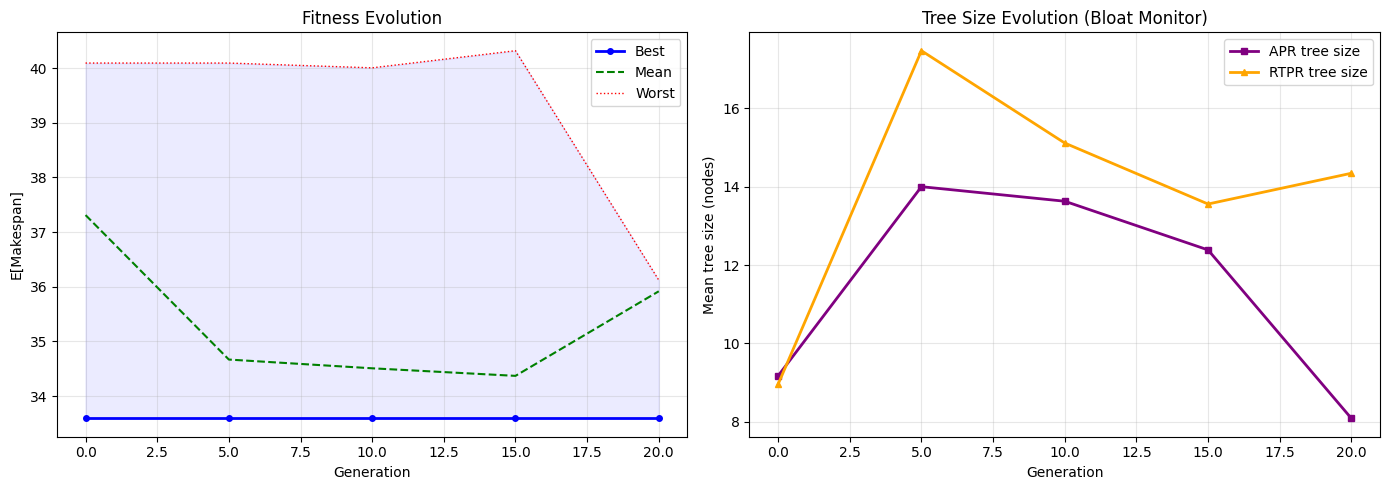

Chart đã lưu vào gp_fitness.png


In [8]:
import matplotlib.pyplot as plt

history = result.history
gens    = [r['gen']   for r in history]
bests   = [r['best']  for r in history]
means   = [r['mean']  for r in history]
worsts  = [r['worst'] for r in history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Fitness evolution ──────────────────────────────────────
ax = axes[0]
ax.plot(gens, bests,  'b-o', markersize=4, label='Best',  linewidth=2)
ax.plot(gens, means,  'g--', markersize=3, label='Mean',  linewidth=1.5)
ax.plot(gens, worsts, 'r:',  markersize=3, label='Worst', linewidth=1)
ax.fill_between(gens, bests, worsts, alpha=0.08, color='blue')
ax.set_xlabel('Generation')
ax.set_ylabel('E[Makespan]')
ax.set_title('Fitness Evolution')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 2: Tree size evolution ────────────────────────────────────
ax2 = axes[1]
apr_sizes  = [r['apr_size']  for r in history]
rtpr_sizes = [r['rtpr_size'] for r in history]
ax2.plot(gens, apr_sizes,  'purple', marker='s', markersize=4,
         label='APR tree size',  linewidth=2)
ax2.plot(gens, rtpr_sizes, 'orange', marker='^', markersize=4,
         label='RTPR tree size', linewidth=2)
ax2.set_xlabel('Generation')
ax2.set_ylabel('Mean tree size (nodes)')
ax2.set_title('Tree Size Evolution (Bloat Monitor)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gp_fitness.png', dpi=120, bbox_inches='tight')
plt.show()
print("Chart đã lưu vào gp_fitness.png")


## Cell 10 — Phân tích cây kết quả

Best fitness (E[makespan]) = 33.5920

RAPR tree  (S-expression):
  (+ (* RR, (min DT, DT)), (max 7.875, (* TS, SLF)))
  Depth: 3 | Size: 11 nodes

RRTPR tree (S-expression):
  (- (neg (max TWC, GAP)), (/ TWC, (neg 2.394)))
  Depth: 3 | Size: 9 nodes

--- Verify trên 50 kịch bản mới (out-of-sample) ---
Mean makespan : 34.650
Min  makespan : 28.204
Max  makespan : 41.436


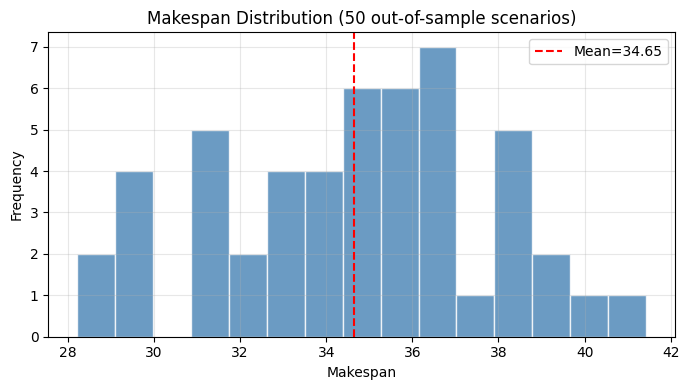

In [9]:
# In chi tiết cá thể tốt nhất
best = result.best

print("=" * 55)
print(f"Best fitness (E[makespan]) = {best.fitness:.4f}")
print("=" * 55)

print(f"\nRAPR tree  (S-expression):")
print(f"  {best.apr_tree}")
print(f"  Depth: {tree_depth(best.apr_tree)} | Size: {tree_size(best.apr_tree)} nodes")

print(f"\nRRTPR tree (S-expression):")
print(f"  {best.rtpr_tree}")
print(f"  Depth: {tree_depth(best.rtpr_tree)} | Size: {tree_size(best.rtpr_tree)} nodes")

# Kiểm tra nhanh: chạy best trên 50 kịch bản độc lập để verify
print("\n--- Verify trên 50 kịch bản mới (out-of-sample) ---")
# generate_scenario_set đã định nghĩa ở cell 2
gss = generate_scenario_set
test_scenarios = gss(project, 50)
makespans = [simulate(s, best.apr_tree, best.rtpr_tree) for s in test_scenarios]
mean_ms = sum(makespans) / len(makespans)
min_ms  = min(makespans)
max_ms  = max(makespans)
print(f"Mean makespan : {mean_ms:.3f}")
print(f"Min  makespan : {min_ms:.3f}")
print(f"Max  makespan : {max_ms:.3f}")

# Distribution
plt.figure(figsize=(7, 4))
plt.hist(makespans, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(mean_ms, color='red', linestyle='--', label=f'Mean={mean_ms:.2f}')
plt.xlabel('Makespan')
plt.ylabel('Frequency')
plt.title('Makespan Distribution (50 out-of-sample scenarios)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Cell FSGP — Fitness Surrogate-assisted GP
Random Forest (thuần Python) xấp xỉ fitness để lọc cá thể kém trước khi simulate.

**17 đặc trưng / cá thể:**
- APR tree (8): depth, size, n_const, const_mean, max_const, n_ops, ratio_binary, ratio_key(SLK/LF)
- RTPR tree (8): depth, size, n_const, const_mean, max_const, n_ops, ratio_binary, ratio_key(TT/GAP)
- Cross (1): apr_depth × rtpr_depth


In [10]:
"""
fsgp.py
───────
FSGP — Fitness Surrogate-assisted Genetic Programming

Thay thế run_gp() bằng run_fsgp() với mô hình Random Forest
xấp xỉ hàm fitness để lọc cá thể kém trước khi simulate thực.

Luồng mỗi thế hệ:
  1. Sinh con cái (crossover / mutate / reproduce) như GP thường
  2. Trích xuất đặc trưng từng cá thể  (extract_features)
  3. Nếu archive đủ lớn → huấn luyện RF → dự đoán fitness con cái
     - Cá thể bị dự đoán kém (> threshold) → thay bằng cha/mẹ
  4. Evaluate thực (simulate) các cá thể còn lại
  5. Lưu vào archive để RF học dần

Đặc trưng (8 đặc trưng trên mỗi cây, tổng 16 + 1 cross):
  APR tree  : depth, size, n_const, const_mean, n_ops, ratio_binary,
              ratio_slk_lf (terminal cụ thể), max_const
  RTPR tree : depth, size, n_const, const_mean, n_ops, ratio_binary,
              ratio_tt_gap, max_const
  Cross     : apr_depth * rtpr_depth  (tương tác)
"""

import random
import time
import math
from copy import deepcopy
from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Dict


# ═══════════════════════════════════════════════════════════════════
# Trích xuất đặc trưng
# ═══════════════════════════════════════════════════════════════════

def _tree_stats(root: Node, tree_type: str) -> dict:
    """
    Tính 8 đặc trưng từ một cây GP.

    F1  depth        — độ sâu cây (0 = leaf)
    F2  size         — tổng số node
    F3  n_const      — số node hằng số
    F4  const_mean   — trung bình giá trị hằng số (0 nếu không có)
    F5  max_const    — hằng số lớn nhất (0 nếu không có)
    F6  n_ops        — số node function
    F7  ratio_binary — tỉ lệ binary op / tổng ops
    F8  ratio_key    — tỉ lệ terminal "quan trọng" (SLK/LF với APR;
                       TT/GAP với RTPR) trên tổng terminal biến
    """
    all_nodes = get_all_nodes(root)

    depth       = tree_depth(root)
    size        = len(all_nodes)

    terminals   = [n for n in all_nodes if n.is_leaf()]
    functions   = [n for n in all_nodes if not n.is_leaf()]

    consts      = [n for n in terminals if n.terminal == 'const']
    vars_       = [n for n in terminals if n.terminal != 'const']

    n_const     = len(consts)
    const_vals  = [n.const for n in consts]
    const_mean  = sum(const_vals) / len(const_vals) if const_vals else 0.0
    max_const   = max(const_vals) if const_vals else 0.0

    n_ops       = len(functions)
    binary_ops  = [n for n in functions if n.op not in ('neg', 'abs')]
    ratio_binary = len(binary_ops) / n_ops if n_ops > 0 else 0.0

    key_terms = {'SLK', 'LF'} if tree_type == 'APR' else {'TT', 'GAP'}
    n_key = sum(1 for n in vars_ if n.terminal in key_terms)
    ratio_key = n_key / len(vars_) if vars_ else 0.0

    return {
        'depth':        depth,
        'size':         size,
        'n_const':      n_const,
        'const_mean':   const_mean,
        'max_const':    max_const,
        'n_ops':        n_ops,
        'ratio_binary': ratio_binary,
        'ratio_key':    ratio_key,
    }


def extract_features(ind: Individual) -> List[float]:
    """
    Trả về vector 17 đặc trưng cho một Individual.

    [0..7]   : APR tree stats
    [8..15]  : RTPR tree stats
    [16]     : apr_depth * rtpr_depth  (tương tác cấu trúc)
    """
    apr  = _tree_stats(ind.apr_tree,  'APR')
    rtpr = _tree_stats(ind.rtpr_tree, 'RTPR')

    vec = [
        # APR
        apr['depth'],
        apr['size'],
        apr['n_const'],
        apr['const_mean'],
        apr['max_const'],
        apr['n_ops'],
        apr['ratio_binary'],
        apr['ratio_key'],
        # RTPR
        rtpr['depth'],
        rtpr['size'],
        rtpr['n_const'],
        rtpr['const_mean'],
        rtpr['max_const'],
        rtpr['n_ops'],
        rtpr['ratio_binary'],
        rtpr['ratio_key'],
        # Cross
        apr['depth'] * rtpr['depth'],
    ]
    return vec


# ═══════════════════════════════════════════════════════════════════
# Random Forest tự cài (không dùng sklearn)
# Dùng thuần Python + thư viện chuẩn
# ═══════════════════════════════════════════════════════════════════

class _DecisionTree:
    """Cây hồi quy đơn giản — CART với max_depth và min_samples_split."""

    def __init__(self, max_depth: int = 5, min_samples: int = 4):
        self.max_depth    = max_depth
        self.min_samples  = min_samples
        self.tree_        = None

    # ── Fit ──────────────────────────────────────────────────────
    def fit(self, X: List[List[float]], y: List[float]):
        self.tree_ = self._build(X, y, depth=0)

    def _build(self, X, y, depth):
        n = len(y)
        if n == 0:
            return 0.0
        mean_y = sum(y) / n

        if depth >= self.max_depth or n < self.min_samples:
            return mean_y

        best_feat, best_thr, best_mse = None, None, float('inf')
        n_feats = len(X[0])

        # Chọn ngẫu nhiên sqrt(n_feats) đặc trưng (như RF)
        k = max(1, int(math.sqrt(n_feats)))
        feat_indices = random.sample(range(n_feats), k)

        for fi in feat_indices:
            thr, mse = self._best_split(X, y, fi)
            if thr is not None and mse < best_mse:
                best_mse, best_feat, best_thr = mse, fi, thr

        if best_feat is None:
            return mean_y

        left_idx  = [j for j in range(n) if X[j][best_feat] <= best_thr]
        right_idx = [j for j in range(n) if X[j][best_feat] >  best_thr]

        return {
            'feat': best_feat,
            'thr':  best_thr,
            'left':  self._build([X[j] for j in left_idx],
                                  [y[j] for j in left_idx], depth + 1),
            'right': self._build([X[j] for j in right_idx],
                                  [y[j] for j in right_idx], depth + 1),
        }

    def _best_split(self, X, y, fi):
        """Tìm ngưỡng tốt nhất cho feature fi — O(n log n) dùng prefix sum.
        Thay thế vòng lặp O(n²) cũ."""
        n = len(y)
        order = sorted(range(n), key=lambda j: X[j][fi])

        # Prefix sums để tính MSE trái/phải trong O(1)
        ps = [0.0] * (n + 1)   # prefix sum of y
        pq = [0.0] * (n + 1)   # prefix sum of y²
        for k, j in enumerate(order):
            ps[k+1] = ps[k] + y[j]
            pq[k+1] = pq[k] + y[j] ** 2

        best_mse, best_thr = float('inf'), None
        for split in range(1, n):
            # Bỏ qua nếu hai mẫu liền kề cùng giá trị feature
            if X[order[split]][fi] == X[order[split - 1]][fi]:
                continue
            nl = split;       nr = n - split
            if nl == 0 or nr == 0:
                continue
            sl = ps[split];   sr = ps[n] - sl
            ql = pq[split];   qr = pq[n] - ql
            # MSE = E[y²] - E[y]² (variance không nhân hệ số)
            mse = (ql - sl*sl/nl) + (qr - sr*sr/nr)
            if mse < best_mse:
                best_mse = mse
                best_thr = (X[order[split-1]][fi] + X[order[split]][fi]) / 2
        return best_thr, best_mse

    @staticmethod
    def _mse(vals):
        if not vals:
            return 0.0
        m = sum(vals) / len(vals)
        return sum((v - m) ** 2 for v in vals) / len(vals)

    # ── Predict ──────────────────────────────────────────────────
    def predict_one(self, x: List[float]) -> float:
        node = self.tree_
        while isinstance(node, dict):
            node = node['left'] if x[node['feat']] <= node['thr'] \
                   else node['right']
        return node


class RandomForestRegressor:
    """
    Random Forest hồi quy thuần Python.
    n_estimators cây, mỗi cây train trên bootstrap sample.
    """

    def __init__(self, n_estimators: int = 30,
                 max_depth: int = 5,
                 min_samples: int = 4):
        self.n_estimators = n_estimators
        self.max_depth    = max_depth
        self.min_samples  = min_samples
        self.trees_: List[_DecisionTree] = []

    def fit(self, X: List[List[float]], y: List[float]):
        self.trees_ = []
        n = len(X)
        for _ in range(self.n_estimators):
            # Bootstrap
            idx = [random.randint(0, n - 1) for _ in range(n)]
            Xb  = [X[i] for i in idx]
            yb  = [y[i] for i in idx]
            tree = _DecisionTree(self.max_depth, self.min_samples)
            tree.fit(Xb, yb)
            self.trees_.append(tree)

    def predict(self, X: List[List[float]]):
        """Trả về (means, stds) — mean và std dự đoán của 30 cây.
        std cao = các cây không đồng thuận = RF không tự tin."""
        means, stds = [], []
        for x in X:
            vals = [t.predict_one(x) for t in self.trees_]
            m = sum(vals) / len(vals)
            var = sum((v - m) ** 2 for v in vals) / len(vals)
            means.append(m)
            stds.append(var ** 0.5)
        return means, stds


# ═══════════════════════════════════════════════════════════════════
# FSGP config
# ═══════════════════════════════════════════════════════════════════

@dataclass
class FSGPConfig:
    """Siêu tham số FSGP = GPConfig + các tham số surrogate."""
    pop_size:       int   = 70
    g_max:          int   = 200
    Q:              int   = 30

    p_crossover:    float = 0.80
    p_mutation:     float = 0.15

    elitism:        int   = 2
    tournament_k:   int   = 3      # nhỏ hơn → giữ diversity tốt hơn

    min_depth:      int   = 2
    max_depth_init: int   = 6
    max_depth_cx:   int   = 8
    max_depth_mut:  int   = 6

    seed:           Optional[int] = None
    log_every:      int   = 10

    # Sinh lại scenarios mỗi N thế hệ để tránh GP overfit tập cố định
    scenario_refresh_every: int = 10   # 0 = không refresh

    # ── Surrogate ────────────────────────────────────────────────
    # Cần ít nhất n_warmup cá thể trong archive trước khi dùng RF
    n_warmup:       int   = 100  # đợi archive đủ lớn trước khi RF bắt đầu lọc

    # Ngưỡng lọc: cá thể bị dự đoán tệ hơn (best + threshold_ratio *
    # (worst - best)) thì bị loại
    threshold_ratio: float = 0.7   # lọc thoáng hơn, chỉ loại cá thể rõ ràng tệ

    # Chỉ lọc khi RF tự tin: std giữa 30 cây < rf_std_threshold
    # std cao = các cây bất đồng = không nên tin RF
    # None = không kiểm tra std (tắt tính năng này)
    rf_std_ratio:   float = 0.3   # std < 0.3 × (worst-best) mới lọc

    # Tham số RF
    rf_n_trees:     int   = 30
    rf_max_depth:   int   = 5

    # Giới hạn archive để tránh RF train chậm dần theo thế hệ
    max_archive:    int   = 300   # chỉ giữ 300 mẫu gần nhất (sliding window)
    # Train lại RF mỗi N thế hệ thay vì mỗi thế hệ
    rf_retrain_every: int = 5


# ═══════════════════════════════════════════════════════════════════
# FSGP helpers
# ═══════════════════════════════════════════════════════════════════

def _train_rf(archive_X: List[List[float]],
              archive_y: List[float],
              cfg: FSGPConfig) -> RandomForestRegressor:
    rf = RandomForestRegressor(
        n_estimators=cfg.rf_n_trees,
        max_depth=cfg.rf_max_depth,
    )
    rf.fit(archive_X, archive_y)
    return rf


def _filter_with_surrogate(
        offspring:    List[Individual],
        parents_map:  Dict[int, Individual],   # id(child) → parent
        rf:           RandomForestRegressor,
        archive_y:    List[float],
        cfg:          FSGPConfig,
) -> List[Individual]:
    """
    Dự đoán fitness con cái bằng RF.
    Cá thể bị dự đoán kém → thay bằng cha/mẹ.
    Trả về danh sách đã lọc (cùng thứ tự, cùng độ dài).
    """
    X_off        = [extract_features(ind) for ind in offspring]
    y_pred, stds = rf.predict(X_off)   # means + stds từ 30 cây

    best_known  = min(archive_y)
    worst_known = max(archive_y)
    spread      = worst_known - best_known
    threshold   = best_known + cfg.threshold_ratio * spread

    # Ngưỡng std: nếu std > std_threshold thì RF không tự tin → không lọc
    std_threshold = cfg.rf_std_ratio * spread if spread > 0 else float('inf')

    filtered = []
    n_replaced = 0
    for ind, pred, std in zip(offspring, y_pred, stds):
        # Chỉ loại khi: (1) dự đoán tệ VÀ (2) RF tự tin (std thấp)
        if pred > threshold and std < std_threshold:
            parent = parents_map.get(id(ind))
            filtered.append(deepcopy(parent) if parent else deepcopy(ind))
            n_replaced += 1
        else:
            filtered.append(ind)

    return filtered, n_replaced


# ═══════════════════════════════════════════════════════════════════
# FSGP — vòng lặp chính
# ═══════════════════════════════════════════════════════════════════

@dataclass
class FSGPResult:
    best:            Individual
    history:         List[dict]
    total_time_s:    float
    n_sim_saved:     int      # số lần simulate được tiết kiệm nhờ surrogate
    n_sim_total:     int      # tổng số simulate nếu không dùng surrogate


def run_fsgp(project: Project,
             config:  FSGPConfig = FSGPConfig()) -> FSGPResult:
    """
    Chạy FSGP trên bài toán RCPSP.

    Trả về FSGPResult chứa cá thể tốt nhất, lịch sử và thống kê surrogate.
    """
    if config.seed is not None:
        random.seed(config.seed)

    t_start = time.perf_counter()

    # ── Sinh kịch bản ──────────────────────────────────────────
    print(f'[FSGP] Sinh {config.Q} kịch bản mô phỏng...')
    scenarios = generate_scenario_set(project, config.Q)

    # ── Khởi tạo quần thể ──────────────────────────────────────
    print(f'[FSGP] Khởi tạo quần thể {config.pop_size} cá thể...')
    population = init_population(
        pop_size=config.pop_size,
        min_depth=config.min_depth,
        max_depth=config.max_depth_init,
    )

    # Evaluate toàn bộ thế hệ đầu (warm-up cho RF)
    for ind in population:
        evaluate_individual(ind, scenarios)
    population.sort(key=lambda x: x.fitness)

    best = deepcopy(population[0])

    # ── Archive ────────────────────────────────────────────────
    archive_X: List[List[float]] = [extract_features(ind) for ind in population]
    archive_y: List[float]       = [ind.fitness           for ind in population]

    rf: Optional[RandomForestRegressor] = None
    history    = []
    n_sim_saved  = 0
    n_sim_total  = 0   # = tất cả cá thể sinh ra × Q

    _log_fsgp(0, population, best, history, n_replaced=0, rf_active=False)

    # ── Vòng lặp tiến hóa ──────────────────────────────────────
    for gen in range(1, config.g_max + 1):

        # ── Refresh scenarios để tránh overfit tập cố định ──────
        if config.scenario_refresh_every > 0 \
                and gen % config.scenario_refresh_every == 0:
            scenarios = generate_scenario_set(project, config.Q)
            # Re-evaluate toàn bộ quần thể trên scenarios mới
            for ind in population:
                evaluate_individual(ind, scenarios)
                archive_X.append(extract_features(ind))
                archive_y.append(ind.fitness)
            population.sort(key=lambda x: x.fitness)
            if population[0].fitness < best.fitness:
                best = deepcopy(population[0])
            # Trim archive sau khi thêm batch mới
            if len(archive_y) > config.max_archive:
                archive_X = archive_X[-config.max_archive:]
                archive_y = archive_y[-config.max_archive:]

        new_pop    : List[Individual]       = []
        parents_map: Dict[int, Individual]  = {}

        # Elitism
        for ind in population[:config.elitism]:
            elite = deepcopy(ind)
            new_pop.append(elite)

        # Sinh con cái — ghi nhớ cha/mẹ để revert nếu RF lọc
        while len(new_pop) < config.pop_size:
            roll = random.random()

            if roll < config.p_crossover:
                p1 = tournament_select(population, config.tournament_k)
                p2 = tournament_select(population, config.tournament_k)
                c1, c2 = crossover(p1, p2, config.max_depth_cx)
                for c in [c1, c2]:
                    parents_map[id(c)] = p1   # dùng p1 làm đại diện cha
                new_pop.extend([c1, c2])

            elif roll < config.p_crossover + config.p_mutation:
                p = tournament_select(population, config.tournament_k)
                m = mutate(p, config.max_depth_mut)
                parents_map[id(m)] = p
                new_pop.append(m)

            else:
                p = tournament_select(population, config.tournament_k)
                r = deepcopy(p)
                parents_map[id(r)] = p
                new_pop.append(r)

        population = new_pop[:config.pop_size]

        # Tách elite (đã có fitness) khỏi offspring cần evaluate
        elites   = population[:config.elitism]
        offspring = population[config.elitism:]

        n_replaced = 0
        rf_active  = False

        # ── Lọc bằng surrogate nếu archive đủ lớn ────────────
        if len(archive_y) >= config.n_warmup:
            rf_active = True
            # Train lại RF mỗi rf_retrain_every thế hệ (không phải mỗi gen)
            if rf is None or gen % config.rf_retrain_every == 0:
                rf = _train_rf(archive_X, archive_y, config)
            offspring, n_replaced = _filter_with_surrogate(
                offspring, parents_map, rf, archive_y, config
            )
            n_sim_saved += n_replaced

        n_sim_total += len(offspring)

        # ── Evaluate thực các cá thể còn lại ─────────────────
        for ind in offspring:
            if ind.fitness == float('inf'):
                evaluate_individual(ind, scenarios)
                # Lưu vào archive
                archive_X.append(extract_features(ind))
                archive_y.append(ind.fitness)

        # Sliding window: giữ chỉ max_archive mẫu gần nhất
        if len(archive_y) > config.max_archive:
            archive_X = archive_X[-config.max_archive:]
            archive_y = archive_y[-config.max_archive:]

        population = elites + offspring
        population.sort(key=lambda x: x.fitness)

        if population[0].fitness < best.fitness:
            best = deepcopy(population[0])

        if gen % config.log_every == 0 or gen == config.g_max:
            _log_fsgp(gen, population, best, history, n_replaced, rf_active)

    total_time = time.perf_counter() - t_start
    print(f'\n[FSGP] Kết thúc sau {total_time:.1f}s | '
          f'Best makespan = {best.fitness:.4f}')
    print(f'[FSGP] Simulate tiết kiệm: {n_sim_saved} '
          f'/ {n_sim_total + n_sim_saved} '
          f'({100*n_sim_saved/(n_sim_total+n_sim_saved+1e-9):.1f}%)')
    print(f'[FSGP] APR  tree: {best.apr_tree}')
    print(f'[FSGP] RTPR tree: {best.rtpr_tree}')

    return FSGPResult(
        best=best,
        history=history,
        total_time_s=total_time,
        n_sim_saved=n_sim_saved,
        n_sim_total=n_sim_total,
    )


# ═══════════════════════════════════════════════════════════════════
# Logging
# ═══════════════════════════════════════════════════════════════════

def _log_fsgp(gen, population, best, history, n_replaced, rf_active):
    fitnesses  = [ind.fitness for ind in population]
    mean_fit   = sum(fitnesses) / len(fitnesses)
    worst_fit  = max(fitnesses)

    apr_sizes  = [tree_size(ind.apr_tree)  for ind in population]
    rtpr_sizes = [tree_size(ind.rtpr_tree) for ind in population]

    record = {
        'gen':        gen,
        'best':       best.fitness,
        'mean':       mean_fit,
        'worst':      worst_fit,
        'apr_size':   sum(apr_sizes)  / len(apr_sizes),
        'rtpr_size':  sum(rtpr_sizes) / len(rtpr_sizes),
        'n_replaced': n_replaced,
        'rf_active':  rf_active,
    }
    history.append(record)

    rf_tag = '[RF]' if rf_active else '[--]'
    print(
        f'Gen {gen:4d} {rf_tag} | '
        f'best={best.fitness:8.3f} | '
        f'mean={mean_fit:8.3f} | '
        f'worst={worst_fit:8.3f} | '
        f'replaced={n_replaced:3d} | '
        f'APR_sz={sum(apr_sizes)/len(apr_sizes):5.1f} | '
        f'RTPR_sz={sum(rtpr_sizes)/len(rtpr_sizes):5.1f}'
    )


## Cell Chạy — So sánh GP vs FSGP


In [11]:
import matplotlib.pyplot as plt

# ════════════════════════════════════════════════════
# THAM SỐ
# ════════════════════════════════════════════════════

project = build_medium_instance(n_real=20)  # instance lớn hơn → fitness landscape phong phú hơn

BASE_CFG = dict(
    pop_size       = 70,
    g_max          = 100,
    Q              = 100,
    p_crossover    = 0.80,
    p_mutation     = 0.15,
    elitism        = 2,
    tournament_k   = 3,     # nhỏ hơn → diversity tốt hơn
    min_depth      = 2,
    max_depth_init = 4,
    max_depth_cx   = 6,
    max_depth_mut  = 4,
    scenario_refresh_every = 10,  # tránh overfit scenarios cố định
    seed           = random.randint(0, 10**6),  # random mỗi lần nhưng GP & FSGP dùng chung
    log_every      = 5,
)

# ── Chạy GP baseline ────────────────────────────────
print("=" * 60)
print("GP BASELINE")
print("=" * 60)
gp_cfg = GPConfig(**BASE_CFG)
gp_result = run_gp(project, gp_cfg)

# ── Chạy FSGP ───────────────────────────────────────
print()
print("=" * 60)
print("FSGP (surrogate-assisted)")
print("=" * 60)
fsgp_cfg = FSGPConfig(
    **BASE_CFG,
    n_warmup        = 20,     # cần ít nhất 20 mẫu trong archive trước khi RF bật
    threshold_ratio = 0.5,    # lọc cá thể tệ hơn 50% khoảng [best, worst]
    rf_n_trees      = 30,
    rf_max_depth    = 5,
)
fsgp_result = run_fsgp(project, fsgp_cfg)

# ════════════════════════════════════════════════════
# So sánh kết quả
# ════════════════════════════════════════════════════
print()
print("=" * 60)
print("KẾT QUẢ SO SÁNH")
print("=" * 60)
print(f"{'':30s}  {'GP':>10s}  {'FSGP':>10s}")
print(f"{'Best E[makespan]':30s}  {gp_result.best.fitness:10.4f}  {fsgp_result.best.fitness:10.4f}")
print(f"{'Thời gian (s)':30s}  {gp_result.total_time_s:10.2f}  {fsgp_result.total_time_s:10.2f}")
print(f"{'Simulate tiết kiệm':30s}  {'—':>10s}  {fsgp_result.n_sim_saved:>10d}")
pct = 100 * fsgp_result.n_sim_saved / (fsgp_result.n_sim_total + fsgp_result.n_sim_saved + 1e-9)
print(f"{'% tiết kiệm':30s}  {'—':>10s}  {pct:9.1f}%")
print()
print(f"GP   APR : {gp_result.best.apr_tree}")
print(f"GP   RTPR: {gp_result.best.rtpr_tree}")
print(f"FSGP APR : {fsgp_result.best.apr_tree}")
print(f"FSGP RTPR: {fsgp_result.best.rtpr_tree}")

# ════════════════════════════════════════════════════
# Visualize
# ════════════════════════════════════════════════════




GP BASELINE
[GP] Sinh 100 kịch bản mô phỏng...
[GP] Khởi tạo quần thể 70 cá thể...
Gen    0 | best=  48.878 | mean=  51.990 | worst=  56.511 | APR_sz=  8.9 | RTPR_sz=  9.6
Gen    5 | best=  48.771 | mean=  50.842 | worst=  56.612 | APR_sz=  8.3 | RTPR_sz=  8.6
Gen   10 | best=  48.573 | mean=  49.727 | worst=  53.237 | APR_sz=  6.3 | RTPR_sz= 14.3
Gen   15 | best=  48.552 | mean=  49.394 | worst=  53.839 | APR_sz=  6.7 | RTPR_sz= 12.6
Gen   20 | best=  48.502 | mean=  49.011 | worst=  53.226 | APR_sz=  9.3 | RTPR_sz= 16.3
Gen   25 | best=  48.499 | mean=  48.747 | worst=  53.132 | APR_sz= 10.9 | RTPR_sz= 20.5
Gen   30 | best=  48.406 | mean=  48.605 | worst=  50.690 | APR_sz=  9.0 | RTPR_sz= 24.6
Gen   35 | best=  48.399 | mean=  48.604 | worst=  51.499 | APR_sz= 12.6 | RTPR_sz= 21.0
Gen   40 | best=  48.399 | mean=  48.831 | worst=  53.157 | APR_sz= 12.1 | RTPR_sz= 20.9
Gen   45 | best=  48.386 | mean=  48.647 | worst=  51.789 | APR_sz= 21.9 | RTPR_sz= 20.3
Gen   50 | best=  48.386 | 